# NINAAD WAGLE | BTECH AI SEM V | I065 B2 | NLP LAB 3

# Task a : Accessing the Gutenberg corpus and listing all texts

[Project Gutenberg](https://www.gutenberg.org/) is a library of over 70,000 free
ebooks. NLTK includes a small selection of texts from the Project Gutenberg
electronic text archive. Each text is identified by a file id like
`austen-emma.txt` (author-title).

In [1]:
import sys
sys.path.append("..")

import nltk
from nltk.corpus import gutenberg

from preprocessing import ensure_corpus

ensure_corpus("gutenberg")

In [2]:
files = gutenberg.fileids()

print("texts available in the Gutenberg corpus:", len(files))
print()
for fileid in files:
    print(" ", fileid)

texts available in the Gutenberg corpus: 18

  austen-emma.txt
  austen-persuasion.txt
  austen-sense.txt
  bible-kjv.txt
  blake-poems.txt
  bryant-stories.txt
  burgess-busterbrown.txt
  carroll-alice.txt
  chesterton-ball.txt
  chesterton-brown.txt
  chesterton-thursday.txt
  edgeworth-parents.txt
  melville-moby_dick.txt
  milton-paradise.txt
  shakespeare-caesar.txt
  shakespeare-hamlet.txt
  shakespeare-macbeth.txt
  whitman-leaves.txt


# Task b : Statistics for every text in the corpus

The corpus reader gives three views of the same text, each used for one statistic:

- `gutenberg.raw(fileid)` - the text as one string -> **total characters**
- `gutenberg.words(fileid)` - the text as a list of word tokens -> **total words**
- `gutenberg.sents(fileid)` - the text as a list of sentences -> **total sentences**

From these:

- **average characters per word** = characters / words (raw characters include
  spaces and newlines, so the value is slightly higher than the true letter count)
- **Type Token Ratio (TTR)** = unique words (types) / total words (tokens),
  after lowercasing so `The` and `the` count as one type. A higher TTR means
  less word repetition, which means a richer vocabulary.

In [3]:
import pandas as pd

from preprocessing import text_statistics

stats_df = pd.DataFrame([text_statistics(fileid) for fileid in files])
stats_df

,text,words,characters,sentences,avg_chars_per_word,ttr
0,austen-emma.txt,192427,887071,7752,4.61,0.0382
1,austen-persuasion.txt,98171,466292,3747,4.75,0.0594
2,austen-sense.txt,141576,673022,4999,4.75,0.0452
3,bible-kjv.txt,1010654,4332554,30103,4.29,0.0126
4,blake-poems.txt,8354,38153,438,4.57,0.1837
5,bryant-stories.txt,55563,249439,2863,4.49,0.0709
6,burgess-busterbrown.txt,18963,84663,1054,4.46,0.0822
7,carroll-alice.txt,34110,144395,1703,4.23,0.0773
8,chesterton-ball.txt,96996,457450,4779,4.72,0.0859
9,chesterton-brown.txt,86063,406629,3806,4.72,0.0906


In [4]:
def richness_comment(ttr):
    if ttr >= 0.10:
        return "high - rich, varied vocabulary"
    if ttr >= 0.05:
        return "moderate - fair variety, noticeable repetition"
    return "low - a small vocabulary reused heavily"

stats_df["lexical richness"] = stats_df["ttr"].apply(richness_comment)

stats_df.sort_values("ttr", ascending=False)[["text", "words", "ttr", "lexical richness"]]

,text,words,ttr,lexical richness
4,blake-poems.txt,8354,0.1837,"high - rich, varied vocabulary"
16,shakespeare-macbeth.txt,23140,0.1497,"high - rich, varied vocabulary"
15,shakespeare-hamlet.txt,37360,0.1262,"high - rich, varied vocabulary"
14,shakespeare-caesar.txt,25833,0.1174,"high - rich, varied vocabulary"
13,milton-paradise.txt,96825,0.0932,"moderate - fair variety, noticeable repetition"
10,chesterton-thursday.txt,69213,0.0917,"moderate - fair variety, noticeable repetition"
9,chesterton-brown.txt,86063,0.0906,"moderate - fair variety, noticeable repetition"
8,chesterton-ball.txt,96996,0.0859,"moderate - fair variety, noticeable repetition"
6,burgess-busterbrown.txt,18963,0.0822,"moderate - fair variety, noticeable repetition"
17,whitman-leaves.txt,154883,0.0804,"moderate - fair variety, noticeable repetition"


### Comments on lexical richness

- `blake-poems` has the highest TTR (0.18), but it is also the shortest text
  (8,354 words). TTR always looks better on short texts, because words have had
  less chance to repeat - so its lead is partly an artefact of size.
- The three Shakespeare plays score high (0.12 - 0.15) at a moderate length,
  which reflects genuinely varied vocabulary.
- `bible-kjv` has the lowest TTR (0.013): it is by far the longest text
  (over a million words) and its style is deliberately repetitive.
- Because of this length effect, TTR is only a fair comparison between texts of
  similar size.
- Average characters per word barely moves (4.2 - 4.8 across all 18 texts):
  `carroll-alice` sits at the bottom with its simple, child-oriented language,
  and `milton-paradise` at the top.

# Task c : Accessing the Brown corpus and listing all texts

The Brown corpus was the first million-word electronic corpus of English,
created in 1961 at Brown University. It contains 500 text samples drawn from
15 categories (genres) such as news, fiction and religion. Its file ids are
short codes like `ca01`, where the letters mark the category and the number
the sample within it.

In [5]:
from nltk.corpus import brown

ensure_corpus("brown")

brown_files = brown.fileids()

print("texts available in the Brown corpus:", len(brown_files))
print()
print(brown_files)

texts available in the Brown corpus: 500

['ca01', 'ca02', 'ca03', 'ca04', 'ca05', 'ca06', 'ca07', 'ca08', 'ca09', 'ca10', 'ca11', 'ca12', 'ca13', 'ca14', 'ca15', 'ca16', 'ca17', 'ca18', 'ca19', 'ca20', 'ca21', 'ca22', 'ca23', 'ca24', 'ca25', 'ca26', 'ca27', 'ca28', 'ca29', 'ca30', 'ca31', 'ca32', 'ca33', 'ca34', 'ca35', 'ca36', 'ca37', 'ca38', 'ca39', 'ca40', 'ca41', 'ca42', 'ca43', 'ca44', 'cb01', 'cb02', 'cb03', 'cb04', 'cb05', 'cb06', 'cb07', 'cb08', 'cb09', 'cb10', 'cb11', 'cb12', 'cb13', 'cb14', 'cb15', 'cb16', 'cb17', 'cb18', 'cb19', 'cb20', 'cb21', 'cb22', 'cb23', 'cb24', 'cb25', 'cb26', 'cb27', 'cc01', 'cc02', 'cc03', 'cc04', 'cc05', 'cc06', 'cc07', 'cc08', 'cc09', 'cc10', 'cc11', 'cc12', 'cc13', 'cc14', 'cc15', 'cc16', 'cc17', 'cd01', 'cd02', 'cd03', 'cd04', 'cd05', 'cd06', 'cd07', 'cd08', 'cd09', 'cd10', 'cd11', 'cd12', 'cd13', 'cd14', 'cd15', 'cd16', 'cd17', 'ce01', 'ce02', 'ce03', 'ce04', 'ce05', 'ce06', 'ce07', 'ce08', 'ce09', 'ce10', 'ce11', 'ce12', 'ce13', 'ce14', 'ce15

# Task d : Comparing genres (categories) in the Brown corpus

Unlike Gutenberg, the Brown corpus is organised by **genre**: every text belongs
to one of 15 categories, and the reader functions accept a `categories=`
argument to work on one genre at a time.

`brown_category_statistics()` in preprocessing.py compares a genre on three things:

- total words - `len(brown.words(categories=...))`
- total sentences - `len(brown.sents(categories=...))`
- most common words - `nltk.FreqDist()`, a frequency distribution that counts
  how often every word appears

In [6]:
categories = brown.categories()

print("categories in the Brown corpus:", len(categories))
print(categories)

categories in the Brown corpus: 15
['adventure', 'belles_lettres', 'editorial', 'fiction', 'government', 'hobbies', 'humor', 'learned', 'lore', 'mystery', 'news', 'religion', 'reviews', 'romance', 'science_fiction']


In [7]:
from preprocessing import brown_category_statistics

genre_df = pd.DataFrame([brown_category_statistics(category) for category in categories])
genre_df

,category,words,sentences,most_common
0,adventure,69342,4637,"[(., 4057), (,, 3488), (the, 3370), (and, 1622..."
1,belles_lettres,173096,7209,"[(the, 9726), (,, 9166), (., 6397), (of, 6289)..."
2,editorial,61604,2997,"[(the, 3508), (,, 2766), (., 2481), (of, 1976)..."
3,fiction,68488,4249,"[(,, 3654), (., 3639), (the, 3423), (and, 1696..."
4,government,70117,3032,"[(the, 4143), (,, 3405), (of, 3031), (., 2493)..."
5,hobbies,82345,4193,"[(the, 4300), (,, 3849), (., 3453), (of, 2390)..."
6,humor,21695,1053,"[(,, 1331), (the, 930), (., 877), (of, 515), (..."
7,learned,181888,7734,"[(the, 11079), (,, 8242), (of, 7418), (., 6773..."
8,lore,110299,4881,"[(the, 6328), (,, 5519), (., 4367), (of, 3668)..."
9,mystery,57169,3886,"[(., 3326), (,, 2805), (the, 2573), (to, 1284)..."


### Exploring FreqDist()

A `FreqDist` is a dictionary-like counter with some extras: `fd.N()` is the
total tokens counted, `len(fd)` the number of distinct words, `fd["word"]` a
single word's count and `fd.freq("word")` its share of the whole text.

In [8]:
from nltk import FreqDist

news_fd = FreqDist(brown.words(categories="news"))

print("total tokens, fd.N()      :", news_fd.N())
print("distinct words, len(fd)   :", len(news_fd))
print("count of 'the', fd['the'] :", news_fd["the"])
print()
print("10 most common tokens in 'news':")
print(news_fd.most_common(10))

total tokens, fd.N()      : 100554
distinct words, len(fd)   : 14394
count of 'the', fd['the'] : 5580

10 most common tokens in 'news':
[('the', 5580), (',', 5188), ('.', 4030), ('of', 2849), ('and', 2146), ('to', 2116), ('a', 1993), ('in', 1893), ('for', 943), ('The', 806)]


The raw top-10 is nearly identical for every genre - `the`, `of`, `and`,
punctuation - so it says nothing about what makes the genres different.
Removing punctuation and stopwords first (reusing the LAB 1 functions) lets
each genre's own character show through:

In [9]:
from preprocessing import remove_punctuation, remove_stopwords

for category in categories:
    words = [word.lower() for word in brown.words(categories=category)]
    words = remove_stopwords(remove_punctuation(words))
    fd = FreqDist(words)
    print(category, "->", fd.most_common(5))

adventure -> [('said', 288), ('would', 194), ('one', 183), ('back', 166), ('man', 166)]
belles_lettres -> [('one', 550), ('would', 397), ('new', 278), ('time', 231), ('man', 231)]
editorial -> [('would', 185), ('one', 173), ('new', 134), ('mr', 110), ('united', 82)]
fiction -> [('would', 291), ('said', 194), ('one', 184), ('could', 168), ('like', 151)]
government -> [('state', 196), ('states', 184), ('year', 183), ('may', 179), ('united', 155)]
hobbies -> [('one', 286), ('new', 149), ('may', 143), ('time', 133), ('first', 126)]
humor -> [('said', 88), ('one', 77), ('would', 56), ('time', 44), ('even', 39)]
learned -> [('af', 908), ('one', 521), ('may', 336), ('would', 321), ('two', 250)]
lore -> [('one', 361), ('would', 188), ('time', 178), ('may', 170), ('new', 162)]
mystery -> [('said', 204), ('would', 189), ('one', 173), ('back', 158), ('could', 145)]
news -> [('said', 406), ('mrs', 254), ('would', 246), ('new', 241), ('one', 213)]
religion -> [('god', 136), ('one', 104), ('new', 99

# Task e : Accessing text from the web

Any plain-text URL can be read with `urllib.request`. Here we fetch
*Crime and Punishment* (ebook no. 2554) directly from the Project Gutenberg
website. The response is bytes, so it is decoded to a UTF-8 string first.

In [10]:
from urllib import request

url = "https://www.gutenberg.org/files/2554/2554-0.txt"
response = request.urlopen(url)
raw = response.read().decode("utf8")

print(type(raw))
print(len(raw), "characters")
print()
print(raw[1000:1200])

<class 'str'>
1135213 characters

 he
was arrested.

Though neither by temperament nor conviction a revolutionist, Dostoevsky
was one of a little group of young men who met together to read Fourier
and Proudhon. He was accused of “tak


# Task f : Operations on the web text

Three operations on the downloaded book:

- **Tokenization** - split the raw string into word tokens with `word_tokenize()`
- **Collocations** - `nltk.Text.collocations()` lists pairs of words that occur
  together far more often than chance (e.g. names like *Katerina Ivanovna*)
- **Finding a word** - `count()` tells how often a word occurs, and
  `concordance()` shows every occurrence in its surrounding context

In [11]:
from preprocessing import word_tokenize

tokens = word_tokenize(raw)

print("total tokens:", len(tokens))
print(tokens[:20])

total tokens: 253687
['*', '*', '*', 'START', 'OF', 'THE', 'PROJECT', 'GUTENBERG', 'EBOOK', '2554', '*', '*', '*', 'CRIME', 'AND', 'PUNISHMENT', 'By', 'Fyodor', 'Dostoevsky', 'Translated']


In [12]:
text = nltk.Text(tokens)

text.collocations()

Katerina Ivanovna; Pyotr Petrovitch; Pulcheria Alexandrovna; Avdotya
Romanovna; Rodion Romanovitch; Marfa Petrovna; Sofya Semyonovna; old
woman; Porfiry Petrovitch; Amalia Ivanovna; great deal; young man;
Nikodim Fomitch; Ilya Petrovitch; Andrey Semyonovitch; Hay Market;
Dmitri Prokofitch; Good heavens; police station; head clerk


In [13]:
print("count of 'murder':", text.count("murder"))
print()
text.concordance("murder")

count of 'murder': 50

Displaying 25 of 50 matches:
fter this second , quite unexpected murder . He longed to run away from the pl
ld you the beginning then about the murder of the old pawnbroker-woman . Well 
 it ... ” “ Oh , I heard about that murder before and was rather interested in
ent . “ Why , he was accused of the murder , ” Razumihin went on hotly . “ Was
 . Early on the third day after the murder , when they were still dandling Koc
job is on the same staircase as the murder , on the second floor . When I hear
 I found out what I could about the murder , and went home feeling as suspicio
s repeating his old story about the murder : ‘ I know nothing of it , never he
nds at the very day and hour of the murder constitutes an important piece of c
not know how to rob ; he could only murder . It was his first crime , I assure
ounsel ! ” “ You are talking of the murder of the old pawnbroker , I believe ?
omic ideas are not an incitement to murder , and one has but to suppose ... ” 


# Task g : Accessing HTML documents

A web page is HTML markup, not plain text. It is fetched the same way as
Task e with `urllib.request`, but the tags then have to be stripped out -
`BeautifulSoup.get_text()` does that. The example is the BBC News story
used in chapter 3 of the NLTK book.

In [14]:
url = "http://news.bbc.co.uk/2/hi/health/2284783.stm"
html = request.urlopen(url).read().decode("utf8")

print(len(html), "characters of HTML")
print()
print(html[:300])

37306 characters of HTML

<!doctype html public "-//W3C//DTD HTML 4.0 Transitional//EN" "http://www.w3.org/TR/REC-html40/loose.dtd">
<html>
<head>
<title>BBC NEWS | Health | Blondes 'to die out in 200 years'</title>
<meta name="keywords" content="BBC, News, BBC News, news online, world, uk, international, foreign, britis


In [15]:
from bs4 import BeautifulSoup

page_text = BeautifulSoup(html, "html.parser").get_text()

print(len(page_text), "characters after stripping the tags")
print()
print(page_text[:300])

4349 characters after stripping the tags




BBC NEWS | Health | Blondes 'to die out in 200 years'






































NEWS
  SPORT
  WEATHER
  WORLD SERVICE

  A-Z INDEX 

  SEARCH 












































     You are in: Health  
    
    











News Front Page





Africa


Americas


Asia-


# Task h : Operations on the HTML text

The same operations as Task f, now on the cleaned web page: tokenize the text
with `word_tokenize()`, then wrap the tokens in `nltk.Text` to search for a
word with `concordance()`. The story is about a genetics claim, so we look
up the word `gene`.

In [16]:
page_tokens = word_tokenize(page_text)

print("total tokens:", len(page_tokens))
print(page_tokens[:20])

total tokens: 753
['BBC', 'NEWS', '|', 'Health', '|', 'Blondes', "'to", 'die', 'out', 'in', '200', 'years', "'", 'NEWS', 'SPORT', 'WEATHER', 'WORLD', 'SERVICE', 'A-Z', 'INDEX']


In [17]:
page = nltk.Text(page_tokens)

print("count of 'gene':", page.count("gene"))
print()
page.concordance("gene")

count of 'gene': 5

Displaying 7 of 7 matches:
hey say too few people now carry the gene for blondes to last beyond the next 
blonde hair is caused by a recessive gene . In order for a child to have blond
 have blonde hair , it must have the gene on both sides of the family in the g
ere is a disadvantage of having that gene or by chance . They do n't disappear
des would disappear is if having the gene was a disadvantage and I do not thin
r 's Polio campaign launched in Iraq Gene defect explains high blood pressure 
r 's Polio campaign launched in Iraq Gene defect explains high blood pressure 


# Task i : Reading text from a local file on the disk

In [18]:
from preprocessing import read_pdf

speech = read_pdf("budget_speech.pdf")

print(len(speech), "characters")
print()
print(speech[:400])

102207 characters

GOVERNMENT OF INDIA
BUDGET 2026-2027
SPEECH
OF
NIRMALA SITHARAMAN
MINISTER OF FINANCE
February 1,  2026

 
CONTENTS 
 
Page No. 
Introduction 1 
                                                          PART - A                                          
Yuva Shakti and 3 kartavya 2 
Reform Express 3 
First kartavya: to accelerate and sustain economic growth  3 
Second kartavya: fulfil aspirations 


# Task j : Word cloud of the text document

A word cloud draws the most frequent words scaled by how often they occur.
Stopwords are removed first (the NLTK list from LAB 1, plus a few
speech-filler words like *will* and *proposed* that would otherwise drown
out the real content), so what remains shows what the budget speech is
actually about.

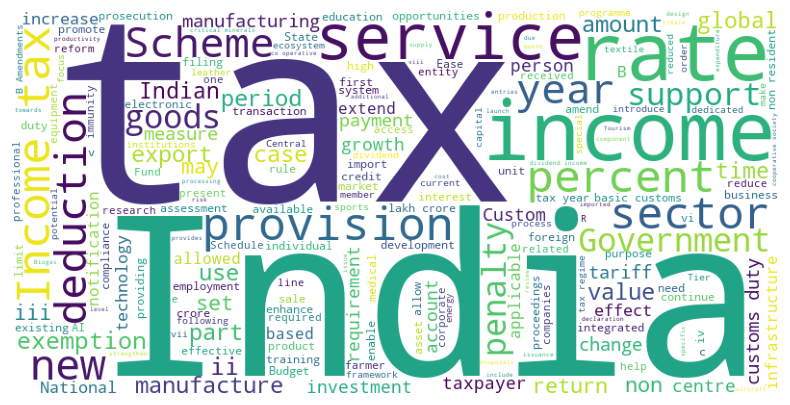

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

from preprocessing import get_stopwords

stops = get_stopwords() | {"will", "shall", "also", "propose", "proposed", "provide", "provided",
                           "per", "cent", "section", "sub", "clause", "act", "amended", "inserted",
                           "said", "made", "certain", "specified", "respect", "including", "nil"}

cloud = WordCloud(width=800, height=400, background_color="white",
                  colormap="viridis", stopwords=stops).generate(speech)

plt.figure(figsize=(10, 5))
plt.imshow(cloud)
plt.axis("off")
plt.show()

### Why a keyword like *kartavya* is missing

The speech is built around "3 kartavya", yet the word does not appear in the
cloud. Two defaults of `WordCloud` explain it:

- `max_words=200` - only the 200 most frequent words are drawn. The cutoff here
  is a count of 8, and `kartavya` ends up at rank 215.
- `collocations=True` - frequent word pairs are counted separately and taken out
  of the single-word count. `kartavya` occurs 13 times, but 6 of those are pulled
  into the pairs *second kartavya* and *third kartavya*, leaving only 7 on its own.

The other reason is the document itself: Part B (the tax and Finance Bill
provisions) is much longer than the policy part, so common words like `section`,
`income`, `rate` and `tax` fill the top of the list.

Setting `collocations=False` or raising `max_words` would bring it back.


In [20]:
from preprocessing import read_pdf

speech = read_pdf("Budget_Speech-2025.pdf")

print(len(speech), "characters")
print()
print(speech[:400])

91663 characters

 
 
Budget 2025-2026 
 
Speech of 
Nirmala Sitharaman 
Minister of Finance 
February 1, 2025 
Hon’ble Speaker,  
 I present the Budget for 2025-26. 
Introduction 
1. This Budget continues our Government’s efforts to: 
a) accelerate growth,  
b) secure inclusive development,  
c) invigorate private sector investments,  
d) uplift household sentiments, and 
e) enhance spending power of India’s risin


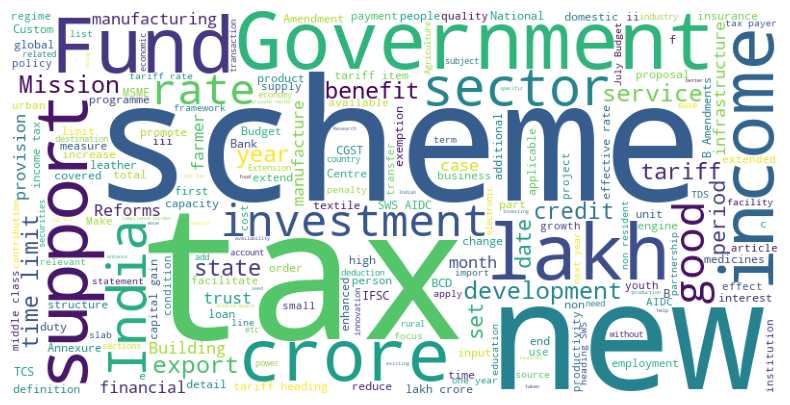

In [21]:
cloud = WordCloud(width=800, height=400, background_color="white",
                  colormap="viridis", stopwords=stops).generate(speech)

plt.figure(figsize=(10, 5))
plt.imshow(cloud)
plt.axis("off")
plt.show()